In [1]:
import pandas as pd
import logging
from marginal_emissions.utils.helper import search_df, check_encoding
logging.basicConfig(level=logging.INFO, format='[%(levelname)s][%(asctime)s][%(filename)s]_%(message)s')

In [5]:
kws_path = '../data/raw/other/bnetza/kraftwerksliste.csv'
cdc_path = '../data/raw/other/bnetza/ZuUndRueckbau.xlsx'  # cdc = commission/decommission

In [11]:
kws_encoding = check_encoding(path=kws_path)

# To check exact column names
kws_cols = pd.read_csv(kws_path, sep=';', skiprows=11, header=0, nrows=5, encoding='Windows-1252')

if kws_encoding:
    kws = pd.read_csv(kws_path, sep=';', skiprows=11, header=0, encoding=kws_encoding, usecols=[
        'Anzeige-Name der Stromerzeugungseinheit',
        'Anlagenbetreiber',
        'Anschlussnetzbetreiber',
        'Bundesland der Einheit',
        'Ort der Einheit',
        'Kraftwerksstatus der Einheit',
        'Energieträger',
        'Speichertechnologie',
        'Wärmeauskopplung (KWK)\n(ja/nein)',
        'Nettonennleistung (elektrische Wirkleistung) in MW',
        'Technologie der Stromerzeugung',
        'Spannungsebene'
    ]).rename(columns={
        'Anzeige-Name der Stromerzeugungseinheit': 'Name',
        'Bundesland der Einheit': 'Bundesland',
        'Ort der Einheit': 'Ort',
        'Kraftwerksstatus der Einheit': 'Status',
        'Wärmeauskopplung (KWK)\n(ja/nein)': 'KWK',
        'Nettonennleistung (elektrische Wirkleistung) in MW': 'Net_Wirkleistung',
        'Technologie der Stromerzeugung': 'Technologie'
    })

    kw_carrier = kws[kws['Energieträger'].str.contains('Speicher', case=False, na=False)].drop(columns='Technologie')
    kw_carrier_pump = kw_carrier[kw_carrier['Speichertechnologie'] == 'Pumpspeicher']
    kw_solar = search_df(kws, 'Solar').copy() # use .copy() to avoid modifying
    kw_solar.Net_Wirkleistung = kw_solar.Net_Wirkleistung.str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float) # makes float from string
    kw_wind = kws[kws['Energieträger'].str.contains('wind', case=False, na=False)].copy()
    kw_wind.Net_Wirkleistung = kw_wind.Net_Wirkleistung.str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float) # makes float from string
    kw_kwk = kws[kws['KWK'] == 'Ja']
    kw_ren = kws[kws['Energieträger'].str.contains('solar|wind', case=False, na=False)]
              #.drop(columns=['Technologie', 'Name', 'Ort', 'Speichertechnologie', 'KWK', 'Anschlussnetzbetreiber']))

    print("# Kraftwerke: ", len(kws))
    print("# Speicher: ", len(kw_carrier_pump))
    print("# Must-Run: ", len(kw_kwk))

    # Einzeiler für eine ganze Spalte
    # df['column_name'] = df['column_name'].str.replace('.', '', regex=False).str.replace(',', '.').astype(float)


[INFO][35007][2026-03-18 12:11:15][helper.py][check_encoding] Checking encoding of file "../data/raw/other/bnetza/kraftwerksliste.csv"...
[INFO][35007][2026-03-18 12:11:15][helper.py][check_encoding] File is encoded as "Windows-1252"
[INFO][35007][2026-03-18 12:11:15][helper.py][search_df] Found 22 rows matching 'Solar' pattern.
# Kraftwerke:  2220
# Speicher:  114
# Must-Run:  1158


In [12]:
kw_ren

,Anlagenbetreiber,Name,Ort,Bundesland,Status,Energieträger,Speichertechnologie,KWK,Net_Wirkleistung,Technologie,Anschlussnetzbetreiber,Spannungsebene
1896,EE-Anlagen,NaN,NaN,Baden-Württemberg,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"11.276,60",NaN,NaN,NaN
1897,EE-Anlagen,NaN,NaN,Bayern,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"24.189,80",NaN,NaN,NaN
1898,EE-Anlagen,NaN,NaN,Berlin,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"334,30",NaN,NaN,NaN
1899,EE-Anlagen,NaN,NaN,Brandenburg,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"6.980,40",NaN,NaN,NaN
1900,EE-Anlagen,NaN,NaN,Bremen,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"120,30",NaN,NaN,NaN
1901,EE-Anlagen,NaN,NaN,Hamburg,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"165,00",NaN,NaN,NaN
1902,EE-Anlagen,NaN,NaN,Hessen,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"4.186,90",NaN,NaN,NaN
1903,EE-Anlagen,NaN,NaN,Mecklenburg-Vorpommern,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"3.720,50",NaN,NaN,NaN
1904,EE-Anlagen,NaN,NaN,Niedersachsen,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"7.983,70",NaN,NaN,NaN
1905,EE-Anlagen,NaN,NaN,Nordrhein-Westfalen,In Betrieb,Solare Strahlungsenergie,NaN,NaN,"10.856,60",NaN,NaN,NaN


In [65]:
kw_gas = kws[kws['Energieträger'].str.contains('gas', case=False, na=False)].drop(columns=['Speichertechnologie', 'Name', 'Anlagenbetreiber', 'Ort']).copy()
kw_gas = kw_gas[kw_gas.Status == 'In Betrieb']
kw_gas = kw_gas[kw_gas.Energieträger == 'Erdgas']
kw_gas = kw_gas[kw_gas.KWK == 'Nein']
kw_gas.Net_Wirkleistung = kw_gas.Net_Wirkleistung.str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
kw_gas = kw_gas[kw_gas.Net_Wirkleistung > 10.0]
kw_gas

,Bundesland,Status,Energieträger,KWK,Net_Wirkleistung,Technologie,Anschlussnetzbetreiber,Spannungsebene
12,Baden-Württemberg,In Betrieb,Erdgas,Nein,45.00,Gasturbinen ohne Abhitzekessel,Netze BW GmbH (SNB948311994307),Hochspannung
13,Baden-Württemberg,In Betrieb,Erdgas,Nein,57.00,Gasturbinen ohne Abhitzekessel,Netze BW GmbH (SNB948311994307),Hochspannung
14,Baden-Württemberg,In Betrieb,Erdgas,Nein,81.00,Gasturbinen ohne Abhitzekessel,Netze BW GmbH (SNB948311994307),Hochspannung
39,Bayern,In Betrieb,Erdgas,Nein,13.84,Verbrennungsmotor,swa Netze GmbH (SNB958077102830),Mittelspannung
153,Sachsen-Anhalt,In Betrieb,Erdgas,Nein,50.00,Gasturbinen ohne Abhitzekessel,Mitteldeutsche Netzgesellschaft Strom mbH (SNB...,Hochspannung
172,Brandenburg,In Betrieb,Erdgas,Nein,56.00,Kondensationsmaschine ohne Entnahme,"DB Energie GmbH (Bahnstromnetz 16,7 Hz) (SNB94...",Hochspannung
173,Brandenburg,In Betrieb,Erdgas,Nein,60.00,Gasturbinen mit nachgeschalteter Dampfturbine,"DB Energie GmbH (Bahnstromnetz 16,7 Hz) (SNB94...",Hochspannung
174,Brandenburg,In Betrieb,Erdgas,Nein,60.00,Gasturbinen mit nachgeschalteter Dampfturbine,"DB Energie GmbH (Bahnstromnetz 16,7 Hz) (SNB94...",Hochspannung
184,Bremen,In Betrieb,Erdgas,Nein,444.50,Gasturbinen mit nachgeschalteter Dampfturbine,wesernetz Bremen GmbH (SNB942238573102),Hochspannung
345,Nordrhein-Westfalen,In Betrieb,Erdgas,Nein,66.70,Gasturbinen ohne Abhitzekessel,Netzgesellschaft Düsseldorf mbH (SNB933956506145),Hochspannung


In [79]:
kw_gas.Technologie.value_counts()

Technologie
Gasturbinen mit nachgeschalteter Dampfturbine    13
Gasturbinen ohne Abhitzekessel                   11
Kondensationsmaschine ohne Entnahme               2
Gasturbinen mit Abhitzekessel                     2
Verbrennungsmotor                                 1
Name: count, dtype: int64

In [76]:
kw_coal = kws[kws['Energieträger'].str.contains('kohle', case=False, na=False)].drop(columns=['Speichertechnologie', 'Name', 'Anlagenbetreiber', 'Ort']).copy()
kw_coal = kw_coal[kw_coal.Status == 'In Betrieb']
#kw_coal = kw_coal[kw_coal.Energieträger == 'Erdgas']
#kw_coal = kw_coal[kw_coal.KWK == 'Nein']
kw_coal.Net_Wirkleistung = kw_coal.Net_Wirkleistung.str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
kw_coal = kw_coal[kw_coal.Net_Wirkleistung > 10.0]
kw_lignite = kw_coal[kw_coal['Energieträger'] == 'Braunkohle']
kw_hardcoal = kw_coal[kw_coal['Energieträger'] == 'Steinkohle']

In [77]:
kw_lignite

,Bundesland,Status,Energieträger,KWK,Net_Wirkleistung,Technologie,Anschlussnetzbetreiber,Spannungsebene
82,Nordrhein-Westfalen,In Betrieb,Braunkohle,Ja,15.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung
83,Nordrhein-Westfalen,In Betrieb,Braunkohle,Ja,628.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung; Mittelspannung; Mittelspannung...
84,Nordrhein-Westfalen,In Betrieb,Braunkohle,Ja,648.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung; Mittelspannung; Mittelspannung...
85,Nordrhein-Westfalen,In Betrieb,Braunkohle,Ja,944.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung; Mittelspannung; Mittelspannung...
167,Sachsen,In Betrieb,Braunkohle,Ja,500.00,Kondensationsmaschine mit Entnahme,50Hertz Transmission GmbH (SNB982046657236),Höchstspannung
168,Sachsen,In Betrieb,Braunkohle,Ja,500.00,Kondensationsmaschine mit Entnahme,50Hertz Transmission GmbH (SNB982046657236),Höchstspannung
169,Sachsen,In Betrieb,Braunkohle,Ja,840.00,Kondensationsmaschine mit Entnahme,50Hertz Transmission GmbH (SNB982046657236),Höchstspannung
170,Sachsen,In Betrieb,Braunkohle,Nein,630.00,Kondensationsmaschine mit Entnahme,50Hertz Transmission GmbH (SNB982046657236),Höchstspannung
409,Nordrhein-Westfalen,In Betrieb,Braunkohle,Ja,663.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung; Höchstspannung; Höchstspannung
411,Nordrhein-Westfalen,In Betrieb,Braunkohle,Ja,656.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung; Höchstspannung; Höchstspannung


In [78]:
kw_hardcoal

,Bundesland,Status,Energieträger,KWK,Net_Wirkleistung,Technologie,Anschlussnetzbetreiber,Spannungsebene
15,Baden-Württemberg,In Betrieb,Steinkohle,Ja,323.00,Kondensationsmaschine mit Entnahme,TransnetBW GmbH (SNB984944755380),Höchstspannung
102,Berlin,In Betrieb,Steinkohle,Ja,89.00,Kondensationsmaschine mit Entnahme,Stromnetz Berlin GmbH (SNB979269087643),Hochspannung
105,Berlin,In Betrieb,Steinkohle,Ja,282.00,Kondensationsmaschine mit Entnahme,50Hertz Transmission GmbH (SNB982046657236); S...,Höchstspannung; Hochspannung
106,Berlin,In Betrieb,Steinkohle,Ja,282.00,Kondensationsmaschine mit Entnahme,50Hertz Transmission GmbH (SNB982046657236); S...,Höchstspannung; Hochspannung
253,Nordrhein-Westfalen,In Betrieb,Steinkohle,Ja,1052.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486); DB Energie Gmb...,Höchstspannung; Hochspannung
321,Nordrhein-Westfalen,In Betrieb,Steinkohle,Ja,725.00,Kondensationsmaschine mit Entnahme,Amprion GmbH (SNB976890256486),Höchstspannung
430,Schleswig-Holstein,In Betrieb,Steinkohle,Ja,32.90,Gegendruckmaschine ohne Entnahme,Stadtwerke Flensburg GmbH (SNB922220582657),Mittelspannung
461,Hessen,In Betrieb,Steinkohle,Ja,61.50,Kondensationsmaschine mit Entnahme,NRM Netzdienste Rhein-Main GmbH (SNB921899277833),Hochspannung
462,Hessen,In Betrieb,Steinkohle,Ja,61.50,Kondensationsmaschine mit Entnahme,NRM Netzdienste Rhein-Main GmbH (SNB921899277833),Hochspannung
596,Hamburg,In Betrieb,Steinkohle,Ja,154.00,Kondensationsmaschine mit Entnahme,Hamburger Energienetze GmbH (SNB968295079586),Hochspannung


In [80]:
mastr = pd.read_csv('../data/raw/other/mastr/Stromerzeuger.csv', sep=';').drop(columns=['Gemarkung', 'Flurstück', 'Gemeindeschlüssel'])

In [81]:
mastr.dropna(axis=1, how='all', inplace=True)
mastr

In [83]:
mastr

,MaStR-Nr. der Einheit,Anzeige-Name der Einheit,Betriebs-Status,Energieträger,Bruttoleistung der Einheit,Nettonennleistung der Einheit,Inbetriebnahmedatum der Einheit,Inbetriebnahmedatum der Einheit am aktuellen Standort,Registrierungsdatum der Einheit,Bundesland,...,Name des Anschluss-Netzbetreibers,MaStR-Nr. des Anschluss-Netzbetreibers,Netzbetreiberprüfung,Spannungsebene,MaStR-Nr. der Lokation,Zuschlagnummer (EEG/KWK-Ausschreibung),MaStR-Nr. der KWK-Anlage,Inbetriebnahmedatum der KWK-Anlage,Elektrische KWK-Leistung,Thermische Nutzleistung in kW
0,SEE959917353245,BHKW 1,In Betrieb,Erdgas,420,"414,8",16.9.2011,NaN,21.2.2019,Niedersachsen,...,EWE NETZ GmbH (SNB951051725711),SNB951051725711,Geprüft,Mittelspannung,SEL999821346452,NaN,KWK969826505215,28.10.2016,420,504
1,SEE916455825825,Oventrop BHKW Olsberg,In Betrieb,Erdgas,240,240,21.1.2014,NaN,1.2.2019,Nordrhein-Westfalen,...,Westnetz GmbH (SNB921897286493),SNB921897286493,Geprüft,Mittelspannung,SEL944271773822,NaN,KWK981516869193,19.12.2013,240,374
2,SEE953230978741,BHKW 1 Fürstenwalde,In Betrieb,Erdgas,1999,1940,5.9.2018,NaN,8.2.2019,Brandenburg,...,E.DIS Netz GmbH (SNB941690671609),SNB941690671609,In Prüfung,Mittelspannung,SEL943898706435,NaN,KWK936954426224,5.9.2018,1940,2050
3,SEE907239270849,Energiezentrale Mönsheim,In Betrieb,Erdgas,238,238,29.12.2016,NaN,1.2.2019,Baden-Württemberg,...,Netze BW GmbH (SNB948311994307),SNB948311994307,Geprüft,Mittelspannung,SEL954756765310,NaN,KWK975957159982,29.12.2016,238,363
4,SEE940378910146,Energiezentrale Mönsheim,In Betrieb,Erdgas,140,140,29.12.2016,NaN,1.2.2019,Baden-Württemberg,...,Netze BW GmbH (SNB948311994307),SNB948311994307,Geprüft,Mittelspannung,SEL918221677898,NaN,KWK978685016763,29.12.2016,140,207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6443,SEE998819218740,"BHKW-Anlage 1, Beethovenstraße 1 (HS Aalen)",In Betrieb,Erdgas,249,249,22.1.2026,NaN,4.2.2026,Baden-Württemberg,...,Stadtwerke Aalen GmbH (SNB982726407335),SNB982726407335,In Prüfung,Niederspannung (= Hausanschluss/Haushaltsstrom),SEL937243495167,NaN,KWK956393621288,22.1.2026,500,720
6444,SEE934919463246,"BHKW-Anlage 2, Beethovenstraße 1 (HS Aalen)",In Betrieb,Erdgas,249,249,22.1.2026,NaN,4.2.2026,Baden-Württemberg,...,Stadtwerke Aalen GmbH (SNB982726407335),SNB982726407335,In Prüfung,Niederspannung (= Hausanschluss/Haushaltsstrom),SEL945257055451,NaN,KWK956393621288,22.1.2026,500,720
6445,SEE967704471027,WEG Tharauer Allee 4-12,In Betrieb,Erdgas,400,400,1.1.2019,NaN,25.2.2026,Berlin,...,Stromnetz Berlin GmbH (SNB979269087643),SNB979269087643,In Prüfung,Niederspannung (= Hausanschluss/Haushaltsstrom),SEL939900545796,NaN,KWK936160597985,1.1.2019,400,400
6446,SEE991880417043,BSZ-Kolk Soandau,In Betrieb,Erdgas,740,722,29.1.2022,NaN,6.3.2026,Berlin,...,Stromnetz Berlin GmbH (SNB979269087643),SNB979269087643,In Prüfung,Niederspannung (= Hausanschluss/Haushaltsstrom),SEL952474180026,NaN,KWK971034793193,29.1.2022,720,19


In [3]:
test = pd.read_csv('../data/processed/final_tennet_2023_15min_utc_202212232315_202401010000.csv', index_col=0)
# Beispiel für delta_generation
print(test['delta_generation'].describe(percentiles=[0.005, 0.01, 0.05, 0.95, 0.99, 0.995]))

count    35812.000000
mean        -0.003295
std         25.499581
min       -262.000000
0.5%       -97.986250
1%         -82.000000
5%         -42.000000
50%          0.000000
95%         39.750000
99%         84.972500
99.5%      102.500000
max        265.250000
Name: delta_generation, dtype: float64


In [6]:
import pandas as pd
from pathlib import Path
import glob

# Define the path to the processed data directory
processed_path = Path('../data/processed')

# Find all 'final_...' csv files in the directory
all_files = glob.glob(str(processed_path / 'final_*.csv'))

# Load all files into a list of dataframes
df_list = [pd.read_csv(file, index_col=0, usecols=['datetime', 'delta_generation', 'delta_emissions']) for file in all_files]

# Concatenate all dataframes into a single one
combined_df = pd.concat(df_list, ignore_index=False)

# Define the percentiles we are interested in
percentiles_to_check = [0.005, 0.01, 0.025, 0.05, 0.95, 0.975, 0.99, 0.995]

print("--- Combined Percentiles for 'delta_generation' ---")
print(combined_df['delta_generation'].describe(percentiles=percentiles_to_check))
print("\n" + "="*50 + "\n")
print("--- Combined Percentiles for 'delta_emissions' ---")
print(combined_df['delta_emissions'].describe(percentiles=percentiles_to_check))

--- Combined Percentiles for 'delta_generation' ---
count    286884.000000
mean         -0.004582
std          35.402528
min        -760.750000
0.5%       -140.250000
1%         -111.750000
2.5%        -77.000000
5%          -52.000000
50%           0.000000
95%          51.000000
97.5%        77.750000
99%         116.250000
99.5%       147.500000
max         877.750000
Name: delta_generation, dtype: float64


--- Combined Percentiles for 'delta_emissions' ---
count    286884.000000
mean         -0.006863
std          26.626820
min        -887.736289
0.5%        -99.661502
1%          -80.338944
2.5%        -56.679054
5%          -39.513153
50%           0.009432
95%          39.610157
97.5%        58.418958
99%          85.388535
99.5%       106.669417
max         884.700252
Name: delta_emissions, dtype: float64


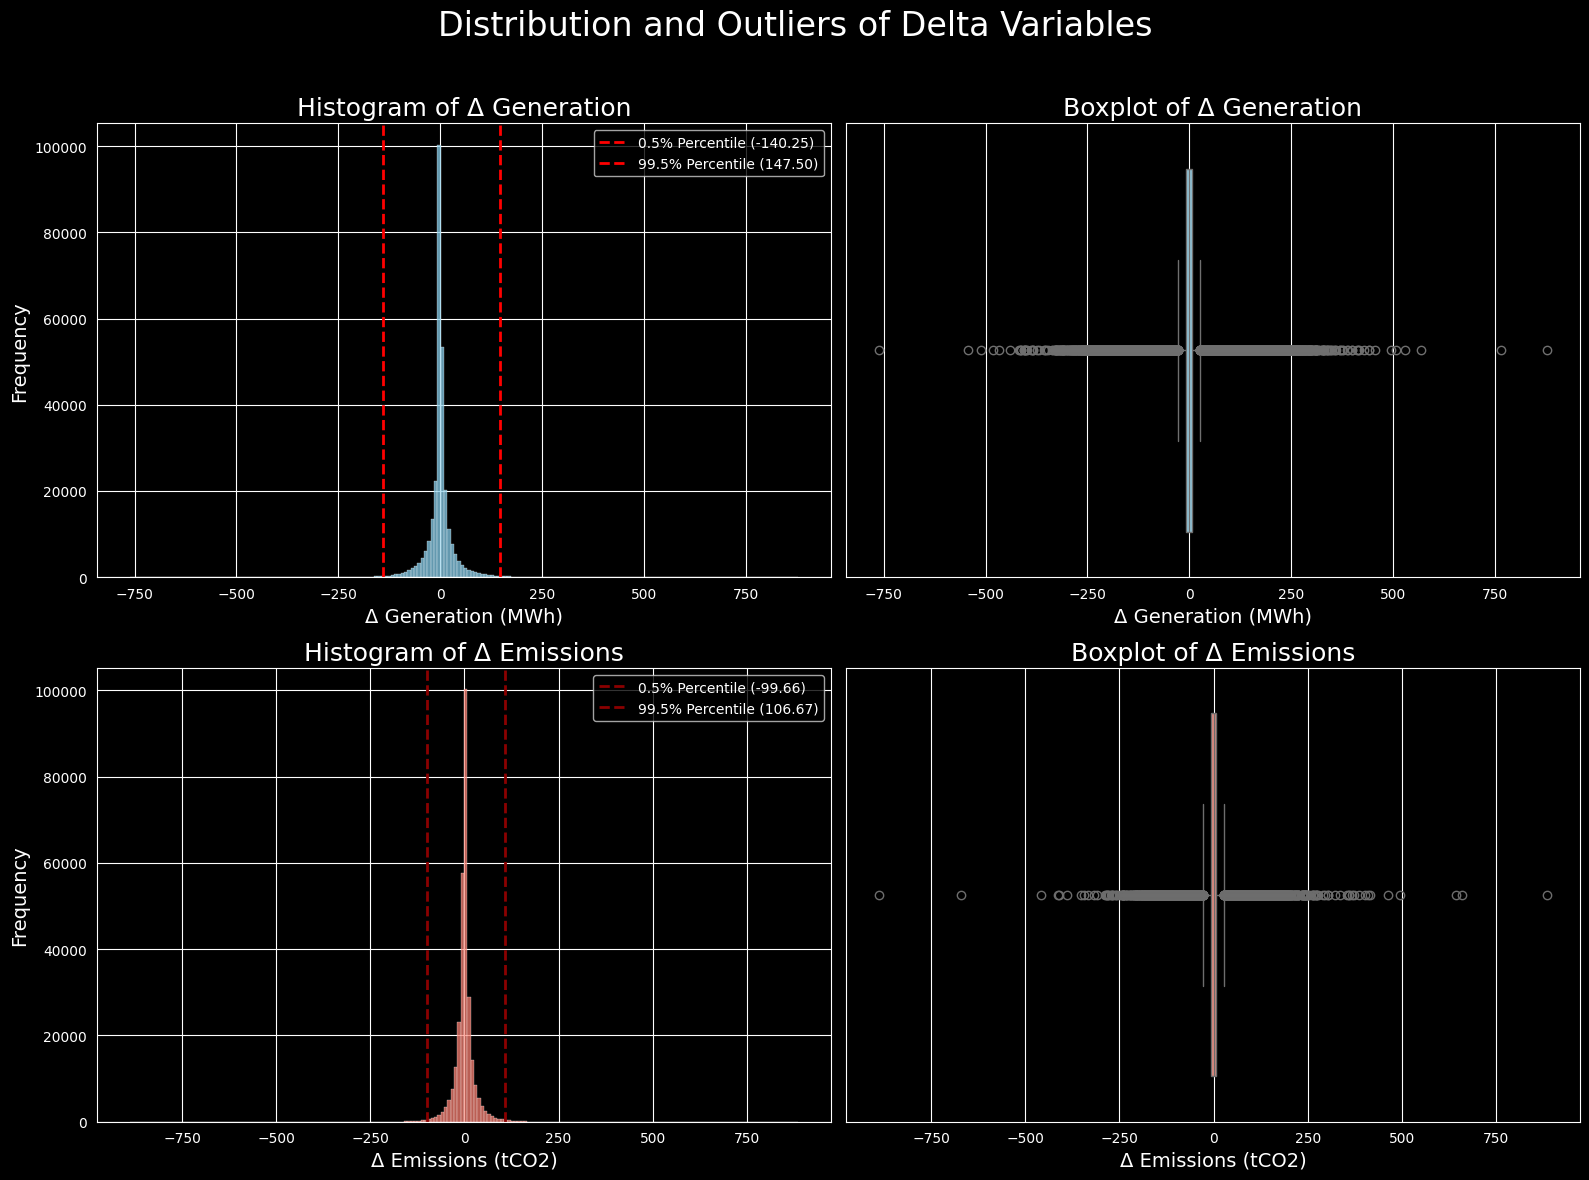

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the clipping limits
gen_lower = -140.25
gen_upper = 147.50
emi_lower = -99.66
emi_upper = 106.67

# Create the figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution and Outliers of Delta Variables', fontsize=24)

# --- Plot 1: Histogram for delta_generation ---
sns.histplot(combined_df['delta_generation'], bins=200, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Histogram of Δ Generation', fontsize=18)
axes[0, 0].set_xlabel('Δ Generation (MWh)', fontsize=14)
axes[0, 0].set_ylabel('Frequency', fontsize=14)
axes[0, 0].axvline(gen_lower, color='red', linestyle='--', linewidth=2, label=f'0.5% Percentile ({gen_lower:.2f})')
axes[0, 0].axvline(gen_upper, color='red', linestyle='--', linewidth=2, label=f'99.5% Percentile ({gen_upper:.2f})')
axes[0, 0].legend()

# --- Plot 2: Boxplot for delta_generation ---
sns.boxplot(x=combined_df['delta_generation'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Boxplot of Δ Generation', fontsize=18)
axes[0, 1].set_xlabel('Δ Generation (MWh)', fontsize=14)

# --- Plot 3: Histogram for delta_emissions ---
sns.histplot(combined_df['delta_emissions'], bins=200, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Histogram of Δ Emissions', fontsize=18)
axes[1, 0].set_xlabel('Δ Emissions (tCO2)', fontsize=14)
axes[1, 0].set_ylabel('Frequency', fontsize=14)
axes[1, 0].axvline(emi_lower, color='darkred', linestyle='--', linewidth=2, label=f'0.5% Percentile ({emi_lower:.2f})')
axes[1, 0].axvline(emi_upper, color='darkred', linestyle='--', linewidth=2, label=f'99.5% Percentile ({emi_upper:.2f})')
axes[1, 0].legend()

# --- Plot 4: Boxplot for delta_emissions ---
sns.boxplot(x=combined_df['delta_emissions'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Boxplot of Δ Emissions', fontsize=18)
axes[1, 1].set_xlabel('Δ Emissions (tCO2)', fontsize=14)

# Adjust layout and save the figure
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = Path('../results/figures/preprocessing_outlier_diagnostics.png')
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()
